<a href="https://colab.research.google.com/github/cyberlynxes/homework/blob/main/400.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
"""
Sector ETF return analysis (extended)

- Modularized: reusable functions for download, metrics, drawdown, saving
- Adds Max Drawdown
- Saves outputs with a prefix
"""

import yfinance as yf
import pandas as pd
import numpy as np

# -----------------------------
# 0. Helpers (shared by Part1/2/3)
# -----------------------------

TRADING_DAYS_PER_YEAR = 252

def download_close_prices(tickers, start, end=None, auto_adjust=True):
    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        interval="1d",
        auto_adjust=auto_adjust,
        progress=False,
    )["Close"]

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.dropna(how="all")
    return data

def max_drawdown_from_growth(growth_series: pd.Series) -> float:
    peak = growth_series.cummax()
    drawdown = growth_series / peak - 1.0
    return float(drawdown.min())

def compute_return_pack(close_prices: pd.DataFrame, risk_free_rate=0.0):
    daily_returns = close_prices.pct_change().dropna()

    cum_growth = (1 + daily_returns).cumprod()
    cum_return = cum_growth.iloc[-1] - 1

    annualized_return = (1 + daily_returns.mean()) ** TRADING_DAYS_PER_YEAR - 1
    annualized_vol = daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

    excess_daily = daily_returns - (risk_free_rate / TRADING_DAYS_PER_YEAR)
    sharpe = (excess_daily.mean() / excess_daily.std()) * np.sqrt(TRADING_DAYS_PER_YEAR)

    max_dd = cum_growth.apply(max_drawdown_from_growth, axis=0)

    summary = pd.DataFrame({
        "Total Return (%)": (cum_return * 100).round(2),
        "Annualized Return (%)": (annualized_return * 100).round(2),
        "Annualized Volatility (%)": (annualized_vol * 100).round(2),
        "Sharpe Ratio": sharpe.round(2),
        "Max Drawdown (%)": (max_dd * 100).round(2),
    }).sort_values("Annualized Return (%)", ascending=False)

    return {
        "close": close_prices,
        "daily_returns": daily_returns,
        "cum_growth": cum_growth,
        "summary": summary
    }

def save_pack(pack, prefix: str):
    pack["summary"].to_csv(f"{prefix}_summary.csv")
    pack["daily_returns"].to_csv(f"{prefix}_daily_returns.csv")
    pack["cum_growth"].to_csv(f"{prefix}_cum_growth.csv")
    pack["close"].to_csv(f"{prefix}_close.csv")

# -----------------------------
# 1. Parameters (Part1)
# -----------------------------

SECTOR_ETFS = [
    "XLE", "XLF", "XLK", "XLY", "XLP",
    "XLI", "XLV", "XLU", "XLRE", "XLB",
]

START_DATE = "2015-01-01"
END_DATE = None
RISK_FREE_RATE = 0.0

# -----------------------------
# 2. Run (Part1)
# -----------------------------

sector_close = download_close_prices(SECTOR_ETFS, START_DATE, END_DATE, auto_adjust=True)
sector_pack = compute_return_pack(sector_close, risk_free_rate=RISK_FREE_RATE)

print("Sector ETF return summary:")
print(sector_pack["summary"])

save_pack(sector_pack, prefix="sector_etf")


Sector ETF return summary:
        Total Return (%)  Annualized Return (%)  Annualized Volatility (%)  \
Ticker                                                                       
XLK               654.53                  25.15                      24.09   
XLI               294.80                  16.45                      19.74   
XLY               231.28                  14.98                      21.78   
XLF               223.66                  14.82                      22.19   
XLE               140.76                  13.79                      29.66   
XLB               195.08                  13.43                      20.69   
XLU               194.85                  13.06                      19.08   
XLV               176.02                  11.85                      16.63   
XLP               137.20                   9.88                      14.64   
XLRE              105.85                   9.51                      20.46   

        Sharpe Ratio  Max Drawdown (

In [4]:
"""
Real estate ETF return analysis (extended)

- Reuses the same helper functions from Part1
- Adds correlation matrix (daily returns)
"""

# -----------------------------
# 1. Parameters (Part2)
# -----------------------------

REAL_ESTATE_ETFS = ["VNQ", "IYR", "SCHH", "XLRE"]

START_DATE_RE = "2010-01-01"
END_DATE_RE = None
RISK_FREE_RATE_RE = 0.0

# -----------------------------
# 2. Run (Part2)
# -----------------------------

re_close = download_close_prices(REAL_ESTATE_ETFS, START_DATE_RE, END_DATE_RE, auto_adjust=True)
re_pack = compute_return_pack(re_close, risk_free_rate=RISK_FREE_RATE_RE)

print("Real estate ETF return summary:")
print(re_pack["summary"])

# Correlation of daily returns
re_corr = re_pack["daily_returns"].corr()
print("\nReal estate ETF daily return correlation:")
print(re_corr.round(3))

save_pack(re_pack, prefix="re_etf")
re_corr.to_csv("re_etf_daily_return_corr.csv")


Real estate ETF return summary:
        Total Return (%)  Annualized Return (%)  Annualized Volatility (%)  \
Ticker                                                                       
XLRE              105.85                   9.51                      20.46   
IYR                85.85                   8.39                      20.24   
VNQ                80.90                   8.20                      20.65   
SCHH               56.73                   6.78                      20.92   

        Sharpe Ratio  Max Drawdown (%)  
Ticker                                  
XLRE            0.44            -38.82  
IYR             0.40            -42.32  
VNQ             0.38            -42.40  
SCHH            0.31            -44.22  

Real estate ETF daily return correlation:
Ticker    IYR   SCHH    VNQ   XLRE
Ticker                            
IYR     1.000  0.987  0.995  0.980
SCHH    0.987  1.000  0.991  0.966
VNQ     0.995  0.991  1.000  0.977
XLRE    0.980  0.966  0.977  1.000


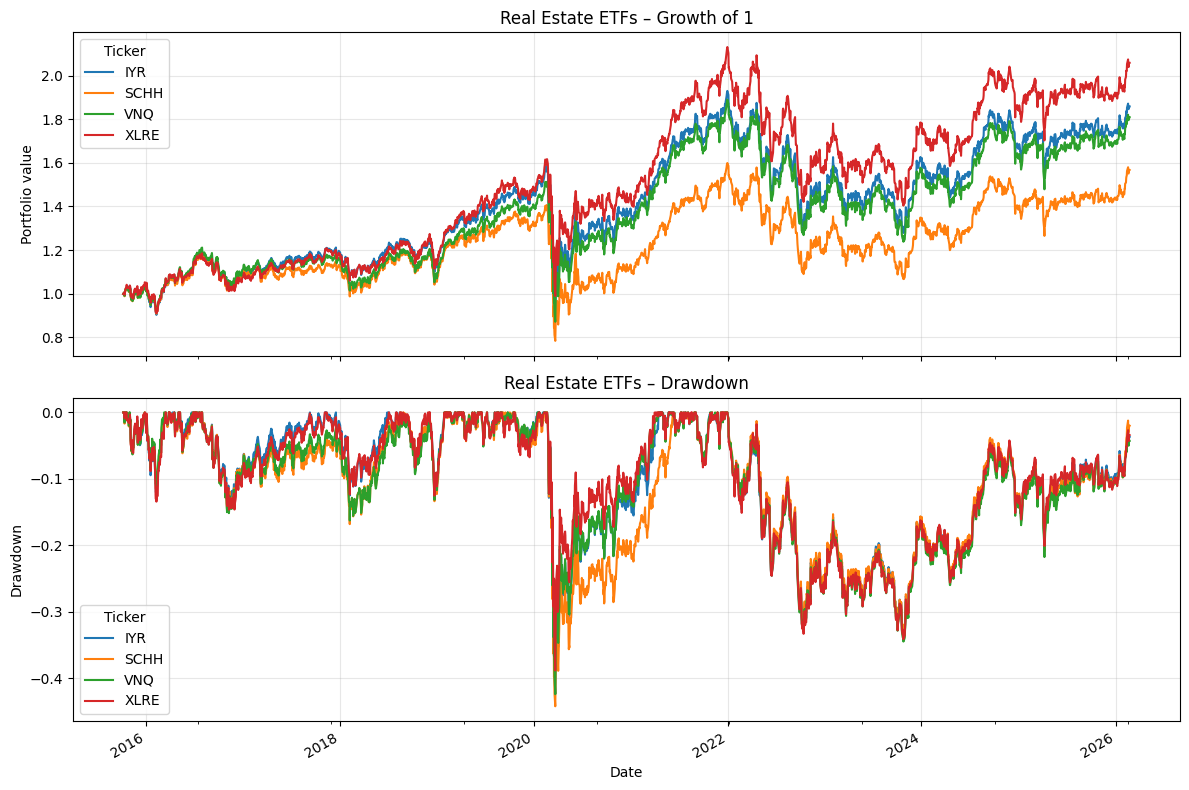

In [5]:
import matplotlib.pyplot as plt

def plot_growth_and_drawdown(cum_growth: pd.DataFrame, title_prefix="ETF"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Growth of 1
    cum_growth.plot(ax=axes[0])
    axes[0].set_title(f"{title_prefix} – Growth of 1")
    axes[0].set_ylabel("Portfolio value")
    axes[0].grid(True, alpha=0.3)

    # Drawdown
    peak = cum_growth.cummax()
    drawdown = cum_growth / peak - 1.0
    drawdown.plot(ax=axes[1])
    axes[1].set_title(f"{title_prefix} – Drawdown")
    axes[1].set_ylabel("Drawdown")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Example: plot real estate ETFs (from Part2)
plot_growth_and_drawdown(re_pack["cum_growth"], title_prefix="Real Estate ETFs")
